# Solid–liquid equilibrium (SLE) with `aiomfac_py.SLESolver`

This notebook demonstrates the SLE solver built on top of AIOMFAC activities and reproduces the figures in
`docs/figs/`. The algorithm follows the primal-dual active-set method of

> Amundson, N. R., Caboussat, A., He, J. W., Seinfeld, J. H. and Yoo, K.-Y.: Primal-dual active-set algorithm for chemical equilibrium problems related to the modeling of atmospheric inorganic aerosols, *J. Optim. Theory Appl.*, 128, 469-498, [doi:10.1007/s10957-006-9030-y](https://doi.org/10.1007/s10957-006-9030-y), 2006.

at fixed T and RH, with a K_sp(T)/hydrate database for atmospheric salts (`aiomfac_py.SOLIDS`). Not part of
AIOMFAC-web and not Fortran-validated. Acid sulfates (NH4HSO4, letovicite, H2SO4 mixtures) are supported by
carrying H+ and SO4-- as *total* amounts and solving HSO4- <-> H+ + SO4-- inside each activity evaluation (Section 7);
gas-phase partitioning (NH3, HNO3, HCl) and acid solids of Na/K are not supported yet.
See `docs/SLE_design_ko.md` for the design, data sources and limitations.

### Setup

In [1]:
from pathlib import Path
import subprocess, sys

REPO_DIR = Path("/content/aiomfac-python")

try:
    import aiomfac_py as aiomfac
    from aiomfac_py import SLESolver  # needs scipy
except ImportError:
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", "https://github.com/SeoulTechPSE/aiomfac-python.git", str(REPO_DIR)],
                        check=True)
    get_ipython().run_line_magic("run", f"{REPO_DIR / 'setup_aiomfac.py'}")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "scipy"], check=True)
    import aiomfac_py as aiomfac

import os, tempfile
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
from aiomfac_py import SOLIDS, SLESolver, feed_from_salts, binary_saturation

# The figure routines live in tools/ (they are the very ones that produce docs/figs/*.png).
for cand in (Path.cwd() / "tools", Path.cwd().parent / "tools", REPO_DIR / "tools"):
    if (cand / "make_sle_figures.py").exists():
        sys.path.insert(0, str(cand)); break
import make_sle_figures as F
F.OUT = tempfile.mkdtemp()           # write to a scratch dir; docs/figs is left untouched
def show(name): display(Image(os.path.join(F.OUT, name)))

print(f"aiomfac_py {aiomfac.__version__}; {len(SOLIDS)} solids in the database")

aiomfac_py 1.0.1; 25 solids in the database


## 1. Basic use: NaCl + (NH4)2SO4 at 298.15 K

`solve(feed, T, RH)` returns the phase state, solid amounts (mol), aqueous water and ion molalities.

In [2]:
sol = SLESolver(["Na+", "NH4+", "Cl-", "SO4--"])
feed = feed_from_salts({"NaCl": 1.0, "(NH4)2SO4": 1.0})
for rh in (0.55, 0.65, 0.70, 0.80, 0.90):
    r = sol.solve(feed, 298.15, rh)
    print(f"RH={rh:.2f}  {r.status:16s} water={r.water_kg*1e3:8.2f} g  solids={ {k: round(v, 3) for k, v in r.solids.items()} }")

RH=0.55  dry              water=    0.00 g  solids={'sal_ammoniac': 1.0, 'thenardite': 0.5, 'ammonium_sulfate': 0.5}
RH=0.65  solid+aqueous    water=  177.43 g  solids={'thenardite': 0.063}
RH=0.70  aqueous          water=  219.69 g  solids={}
RH=0.80  aqueous          water=  330.72 g  solids={}
RH=0.90  aqueous          water=  643.35 g  solids={}


## 2. Fig. 1 -- solubility vs. temperature (fitted vs. anchored K(T))

Saturation molality of ten salts from AIOMFAC with the *anchored* (literature T-dependence + 298 K offset)
and *fitted* (fitted to handbook solubility under AIOMFAC) K(T) against handbook data. The fits are valid
only over roughly 0-60 °C; beyond that the curves are 1/T extrapolations.

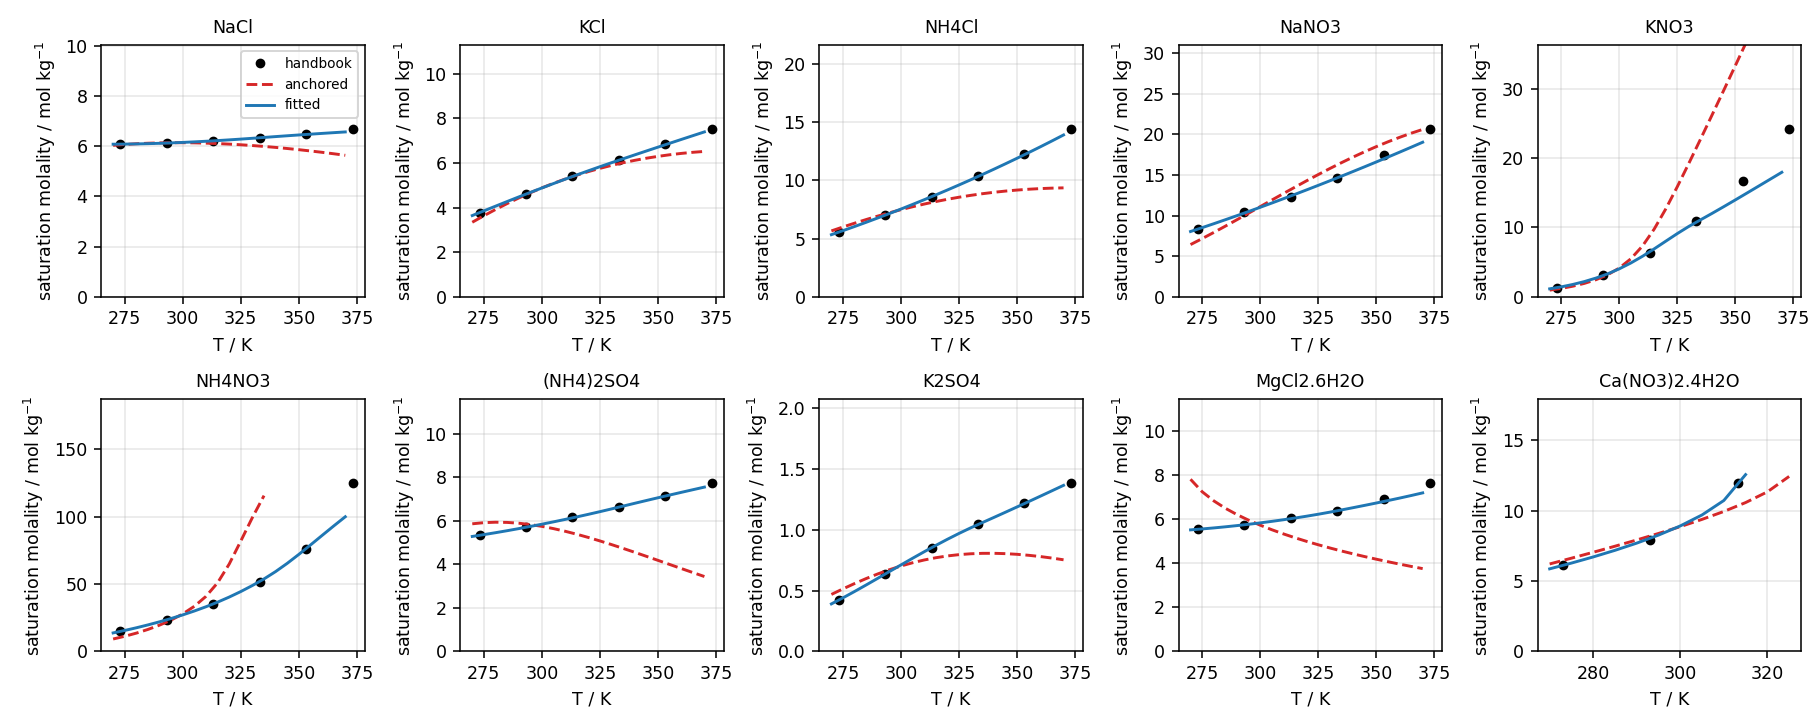

In [3]:
F.fig_solubility(); show("sle_solubility.png")

## 3. Fig. 2 -- deliquescence RH of pure salts vs. temperature

DRH = water activity of the saturated binary solution. NH4NO3 shows the strongest T-dependence.

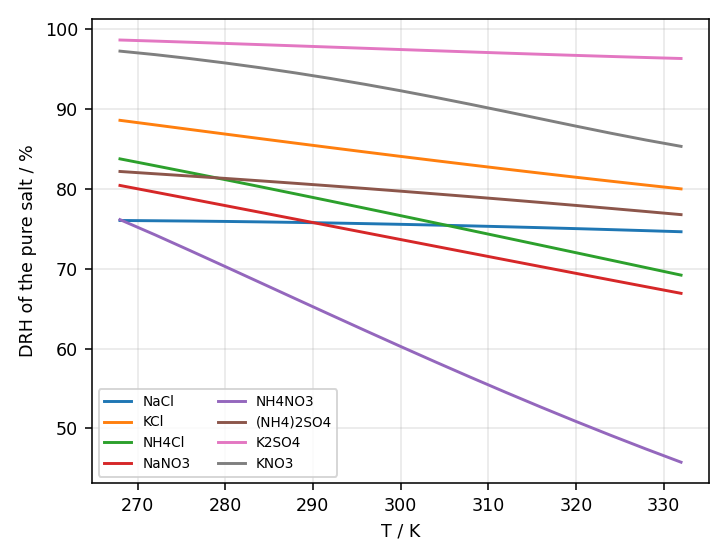

In [4]:
F.fig_drh_T(); show("sle_drh_T.png")

## 4. Fig. 3 -- NaCl-KCl-H2O phase diagram at 298.15 K

Phase state over a composition-RH grid (this takes a minute or so). The mutual DRH is found near 73 %; it
has not yet been compared with the literature DRH/ERH compilations.

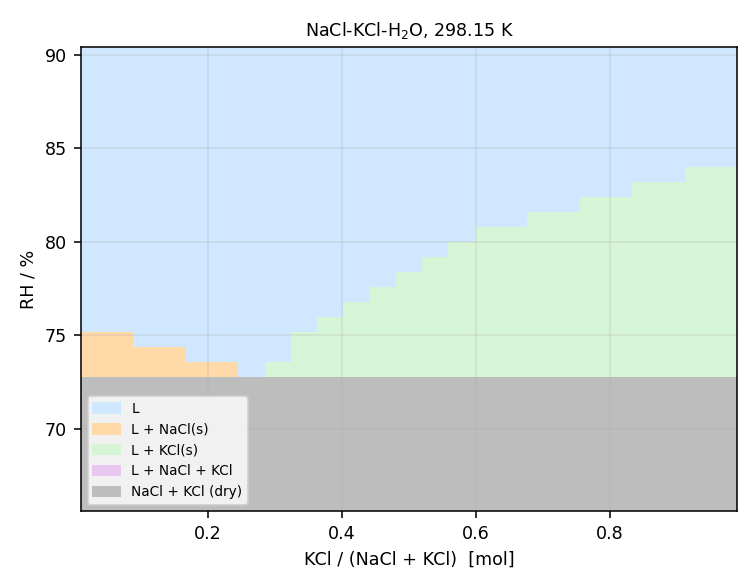

In [5]:
F.fig_phase_nacl_kcl(); show("sle_phase_nacl_kcl.png")

## 5. Fig. 4 -- RH scan of NaCl + (NH4)2SO4

Water content (left) and solid amounts (right) vs. RH. The jump in water at the mutual DRH is physical; below
about 63 % RH the particle is fully dry (NH4Cl + Na2SO4 + (NH4)2SO4 after double decomposition).

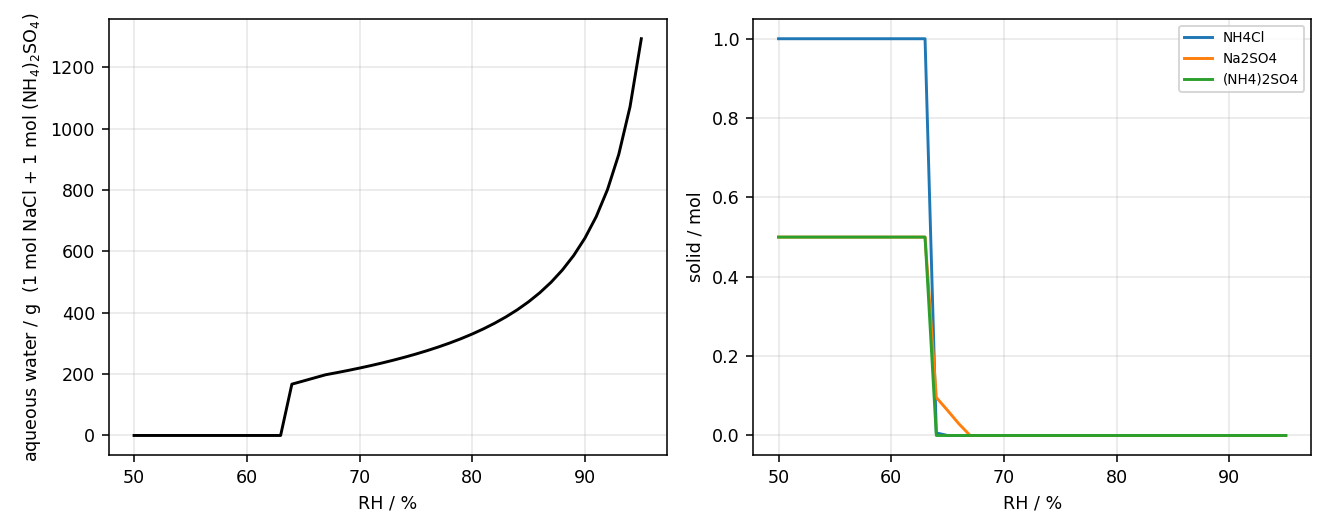

In [6]:
F.fig_scan_mixed(); show("sle_scan_nacl_as.png")

## 6. Mirabilite / thenardite transition and efflorescence

The Na2SO4 hydrate transition (3 mol Na2SO4 at RH 0.85: mirabilite below ~300 K, thenardite above; the pure-water crossing is near 305.5 K), and the kinetic ERH from a user-supplied critical supersaturation.

In [7]:
from aiomfac_py import implied_ln_s_crit
s = SLESolver(["Na+", "SO4--"])
for T in (285.0, 298.15, 303.0, 308.0, 318.0):
    r = s.solve(feed_from_salts({"Na2SO4": 3.0}), T, 0.85)
    print(f"T={T:6.2f} K  RH 0.85: {r.status:8s} solids = { {k: round(v, 2) for k, v in r.solids.items()} }")
print("ln S_crit implied by NaCl ERH ~45 % at 298.15 K:", round(implied_ln_s_crit("halite", 298.15, 0.45), 2))

T=285.00 K  RH 0.85: dry      solids = {'mirabilite': 3.0}
T=298.15 K  RH 0.85: dry      solids = {'mirabilite': 3.0}
T=303.00 K  RH 0.85: dry      solids = {'thenardite': 3.0}
T=308.00 K  RH 0.85: dry      solids = {'thenardite': 3.0}
T=318.00 K  RH 0.85: dry      solids = {'thenardite': 3.0}
ln S_crit implied by NaCl ERH ~45 % at 298.15 K: 3.01


## 7. Acid sulfates: NH4+ / H+ / SO4-- system

H+ and SO4-- are carried as *stoichiometric totals*; the HSO4- <-> H+ + SO4-- equilibrium is solved inside every
activity evaluation (same constant as `aiomfac_py.dissociation`), so a feed is given in total amounts: `"NH4HSO4"`,
`"H2SO4"`, `"(NH4)3H(SO4)2"` or an `HSO4-` entry. The acid solids (NH4HSO4, letovicite, and four Na acid
sulfates) use the thermodynamic constants of Clegg et al. (1998), converted to molality (quality B); the DRH they imply
(NH4HSO4 37.9 %, letovicite 70.1 %; see `tools/calibrate_acid_solids.py`) is an independent check against ~40 / 69.5 %.

Stable assemblage with increasing acidity at 30 % RH, and a pure-H2SO4 solution (which has no solid):

In [8]:
acid = SLESolver(["NH4+", "H+", "SO4--"])
for f_h in (0.2, 0.6, 1.0, 1.8):
    r = acid.solve({"SO4--": 1.0, "H+": f_h, "NH4+": 2.0 - f_h}, 298.15, 0.30)
    print(f"H+/SO4 = {f_h:.1f}: {r.status:8s} solids = { {k: round(v, 2) for k, v in r.solids.items()} }")
r = acid.solve({"SO4--": 1.0, "H+": 2.0}, 298.15, 0.60)
wt = 98.079 / (98.079 + 1000 * r.water_kg)
print(f"H2SO4 solution at a_w = 0.60: {100 * wt:.0f} wt% H2SO4 (handbook value, recalled: about 38-40 wt%; verify)")

H+/SO4 = 0.2: dry      solids = {'ammonium_sulfate': 0.6, 'letovicite': 0.2}


H+/SO4 = 0.6: dry      solids = {'ammonium_bisulfate': 0.2, 'letovicite': 0.4}


H+/SO4 = 1.0: dry      solids = {'ammonium_bisulfate': 1.0}
H+/SO4 = 1.8: aqueous  solids = {}
H2SO4 solution at a_w = 0.60: 38 wt% H2SO4 (handbook value, recalled: about 38-40 wt%; verify)


### Phase map of the NH4+-H+-SO4--H2O system at 298.15 K

Stable assemblage vs. RH and acidity (H+ per sulfate; 0 = (NH4)2SO4, 1 = NH4HSO4, 2 = H2SO4); `L` = aqueous
solution, AS = (NH4)2SO4, LET = letovicite, AHS = NH4HSO4. Takes several minutes (many dry-state stability tests).

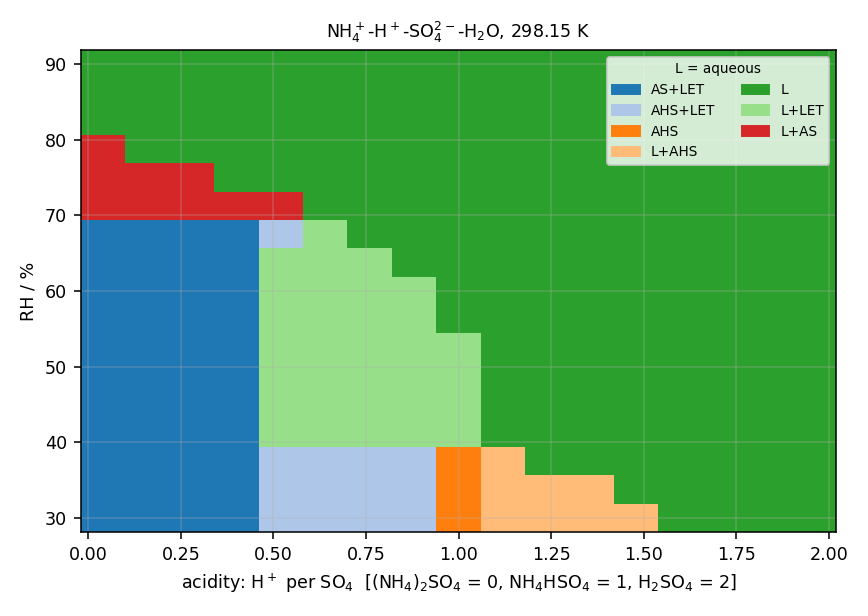

In [9]:
F.fig_acid_phase_map(); show("sle_acid_phase_map.png")